In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import warnings

warnings.filterwarnings("ignore")
df = pd.read_excel('Concrete_Data.xls')
print(df.shape)
df.head()
for c in df.columns:
    print(repr(c))

df = df.rename(columns={
    'Cement (component 1)(kg in a m^3 mixture)': "cement",
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)': "slag",
    'Fly Ash (component 3)(kg in a m^3 mixture)': "ash",
    'Water  (component 4)(kg in a m^3 mixture)': "water",
    'Superplasticizer (component 5)(kg in a m^3 mixture)': "superplasticizer",
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)': "coarse_agg",
    'Fine Aggregate (component 7)(kg in a m^3 mixture)': "fine_agg",
    'Age (day)': "age",
    'Concrete compressive strength(MPa, megapascals) ': "strength"
})
df.columns
df.dtypes
df.isnull().sum()
print("Duplicates:",df.duplicated().sum())
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows. New shape: {df.shape}")


df.describe()
df.to_csv('concrete_clean.csv', index=False)
print("Saved. Final shape:", df.shape)
df.describe()
print((df < 0).sum())
print(df["age"].min(), df["age"].max())
check = pd.read_csv("concrete_clean.csv")
df.to_csv('concrete_clean.csv', index=False)
print("Saved. Final shape:", df.shape)




(1030, 9)
'Cement (component 1)(kg in a m^3 mixture)'
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)'
'Fly Ash (component 3)(kg in a m^3 mixture)'
'Water  (component 4)(kg in a m^3 mixture)'
'Superplasticizer (component 5)(kg in a m^3 mixture)'
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)'
'Fine Aggregate (component 7)(kg in a m^3 mixture)'
'Age (day)'
'Concrete compressive strength(MPa, megapascals) '
Duplicates: 25
Removed 25 duplicate rows. New shape: (1005, 9)
Saved. Final shape: (1005, 9)
cement              0
slag                0
ash                 0
water               0
superplasticizer    0
coarse_agg          0
fine_agg            0
age                 0
strength            0
dtype: int64
1 365
Saved. Final shape: (1005, 9)


In [2]:
check = pd.read_csv("concrete_clean.csv")
print(check.columns.tolist())

['cement', 'slag', 'ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength']


In [3]:
df = pd.read_csv('concrete_clean.csv')
features = ["cement", "slag", "ash", "water", "superplasticizer", "coarse_agg", "fine_agg", "age"]
target = "strength"
df.head()


,cement,slag,ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
print(repr(target))
print(features)

'strength'
['cement', 'slag', 'ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']


In [5]:
corr = df.corr()
print(corr[target].drop(target).sort_values(ascending=False))

cement              0.488283
superplasticizer    0.344225
age                 0.337371
slag                0.103370
ash                -0.080648
coarse_agg         -0.144710
fine_agg           -0.186457
water              -0.269606
Name: strength, dtype: float64


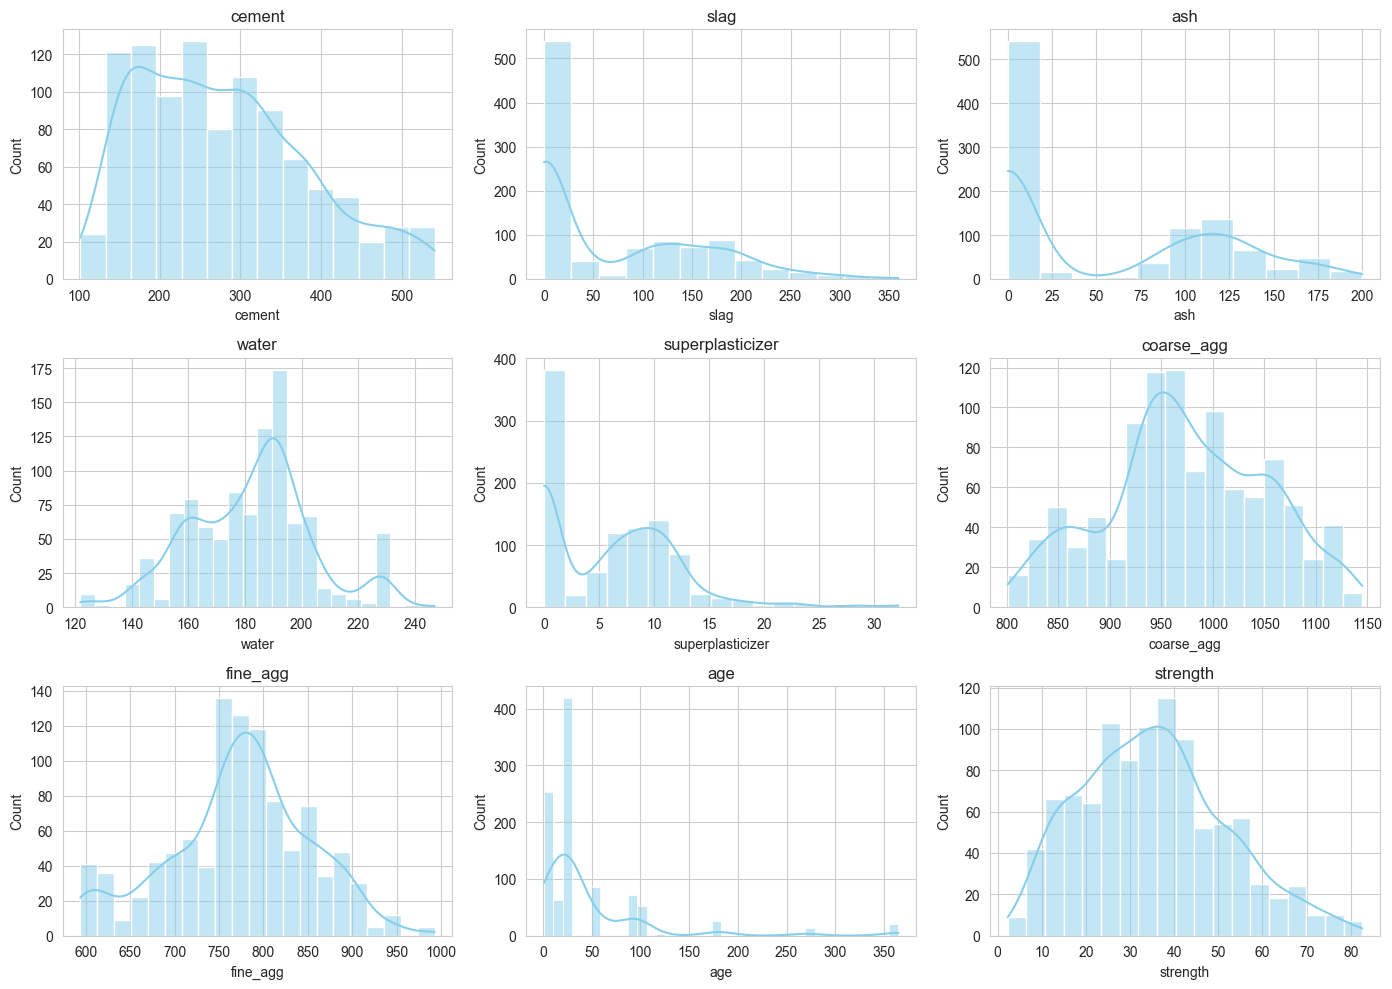

In [6]:
# plotting the distribution of each feature and the target variable
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features + [target]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("01_distribution_plots.png")
plt.show()

<Figure size 100x100 with 0 Axes>

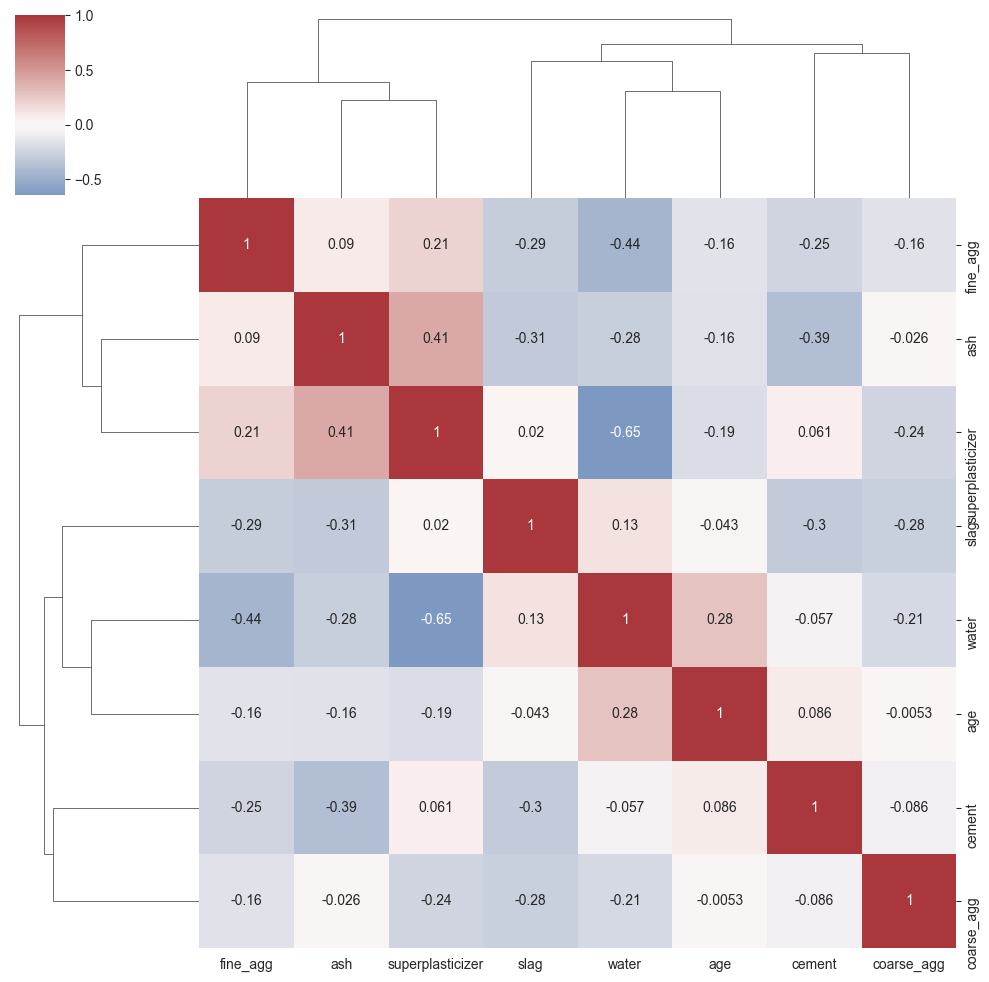

In [7]:
# (heatmap + denfrogram)
plt.figure(figsize=(1,1))
sns.clustermap(df.drop("strength", axis=1).corr(), annot=True, center = 0, cmap="vlag")

In [8]:
# step 3 

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,cement,slag,ash,water,superplasticizer,coarse_agg,fine_agg,age
0,2.506120,-0.836469,-0.865363,-0.941128,-0.596903,0.846308,-1.204069,-0.280312
1,2.506120,-0.836469,-0.865363,-0.941128,-0.596903,1.039755,-1.204069,-0.280312
2,0.516534,0.818051,-0.865363,2.153088,-1.019442,-0.546505,-2.225242,3.518569
3,0.516534,0.818051,-0.865363,2.153088,-1.019442,-0.546505,-2.225242,5.009865
4,-0.767348,0.700784,-0.865363,0.465334,-1.019442,0.051889,0.657702,4.931375


In [11]:
print("Means (should be ~0):")
print(X_scaled_df.mean())
print("\nStd devs (should be 1):")
print(X_scaled_df.std())


Means (should be ~0):
cement             -7.070077e-17
slag               -1.979622e-16
ash                -1.131212e-16
water              -5.656062e-17
superplasticizer    5.656062e-17
coarse_agg         -1.131212e-16
fine_agg           -1.081722e-15
age                -3.535038e-17
dtype: float64

Std devs (should be 1):
cement              1.000498
slag                1.000498
ash                 1.000498
water               1.000498
superplasticizer    1.000498
coarse_agg          1.000498
fine_agg            1.000498
age                 1.000498
dtype: float64


In [12]:
y = df[target]
y.describe()


count    1005.000000
mean       35.250273
std        16.284808
min         2.331808
25%        23.523542
50%        33.798114
75%        44.868340
max        82.599225
Name: strength, dtype: float64

In [13]:
# step 4
from sklearn.decomposition import PCA


In [14]:
my_pca = PCA()
my_pca.fit(X_scaled)
vari_list = my_pca.explained_variance_ratio_
cum_vari = np.cumsum(vari_list)

print("PCA vari Results:")
for i in range(len(vari_list)):
    pc_number = i + 1
    current_vari = vari_list[i]
    current_total = cum_vari[i]

    current_vari_rounded = round(current_vari, 3)
    current_total_rounded = round(current_total, 3)

    print("PC" + str(pc_number) + ": " + str(current_vari_rounded) + " (Total: " + str(current_total_rounded) + ")")



PCA vari Results:
PC1: 0.289 (Total: 0.289)
PC2: 0.179 (Total: 0.468)
PC3: 0.159 (Total: 0.627)
PC4: 0.127 (Total: 0.754)
PC5: 0.121 (Total: 0.874)
PC6: 0.099 (Total: 0.973)
PC7: 0.023 (Total: 0.996)
PC8: 0.004 (Total: 1.0)


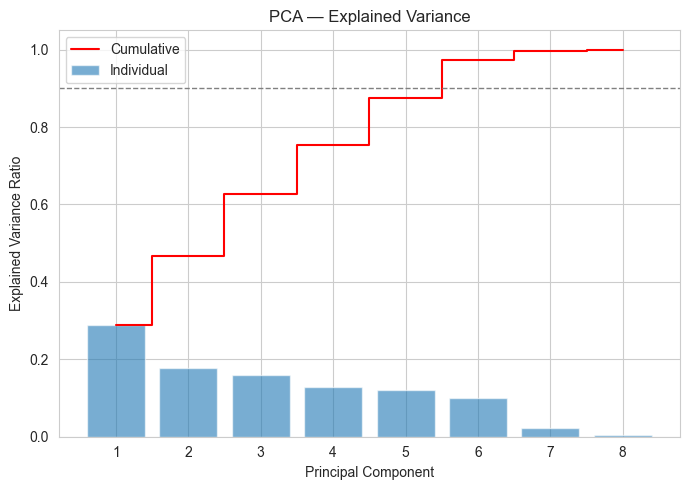

In [15]:
plt.figure(figsize=(7,5))
plt.bar(range(1, len(vari_list)+1), vari_list, alpha=0.6, label="Individual")
plt.step(range(1, len(vari_list)+1), cum_vari, where='mid', color='red', label="Cumulative")
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA — Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("05_pca_variance.png")
plt.show()

In [16]:
n_comp = np.argmax(cum_vari >= 0.90) + 1
print("Comonent needed for >=90% variance:", n_comp)

pca = PCA(n_comp)
X_pca = pca.fit_transform(X_scaled)
print("New shape after PCA:", X_pca.shape)

Comonent needed for >=90% variance: 6
New shape after PCA: (1005, 6)


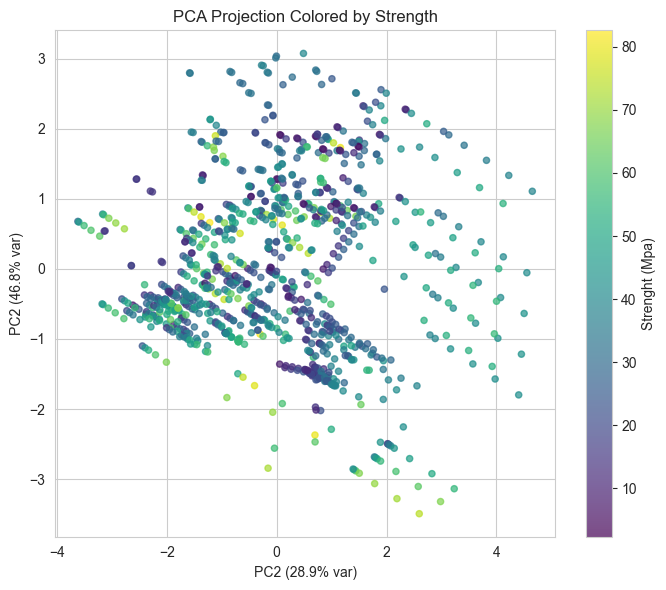

In [17]:
plt.figure(figsize=(7,6))
sc = plt.scatter(X_pca[:,0], X_pca[:,1],c=y, cmap="viridis", alpha=0.7, s=20)
plt.colorbar(sc, label="Strenght (Mpa)")
plt.xlabel(f"PC2 ({vari_list[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({cum_vari[1]*100:.1f}% var)")
plt.title("PCA Projection Colored by Strength")
plt.tight_layout()
plt.savefig("06_pca_scatter_strenght.png")
plt.show()


In [18]:
# step 5 K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
inertias = []
sil_scores =[] 
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={i:.1f}  silhouette={s:.3f}")


k=2: inertia=6180.0  silhouette=0.216
k=3: inertia=5263.4  silhouette=0.241
k=4: inertia=4541.7  silhouette=0.251
k=5: inertia=3856.1  silhouette=0.271
k=6: inertia=3393.3  silhouette=0.293
k=7: inertia=3142.6  silhouette=0.297
k=8: inertia=2957.1  silhouette=0.280


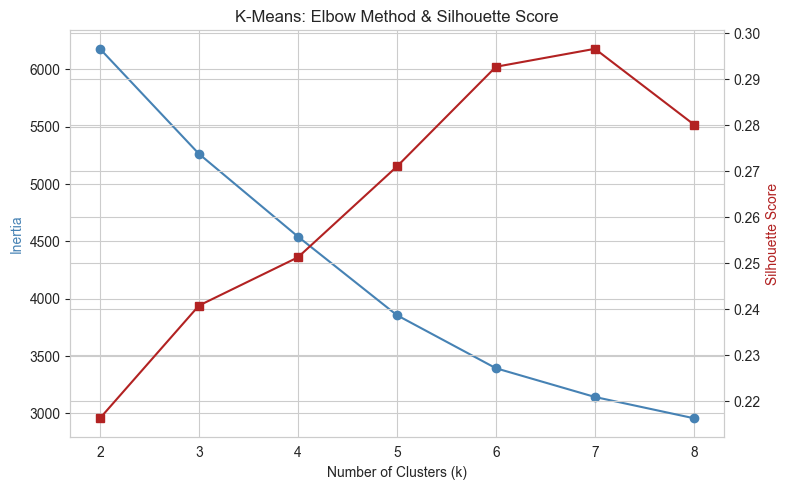

In [20]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(list(K_range), inertias, 'o-', color='steelblue', label='Inertia (Elbow)')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color='steelblue')

ax2 = ax1.twinx()
ax2.plot(list(K_range), sil_scores, 's-', color='firebrick', label='Silhouette Score')
ax2.set_ylabel("Silhouette Score", color='firebrick')

plt.title("K-Means: Elbow Method & Silhouette Score")
fig.tight_layout()
plt.savefig("07_kmeans_elbow_silhouette.png")
plt.show()

In [21]:
best_k = list(K_range)[np.argmax(sil_scores)]
print("Best k by silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters
df['Cluster'].value_counts()

Best k by silhouette score: 7


Cluster
3    280
2    192
4    173
6    146
1    127
0     45
5     42
Name: count, dtype: int64

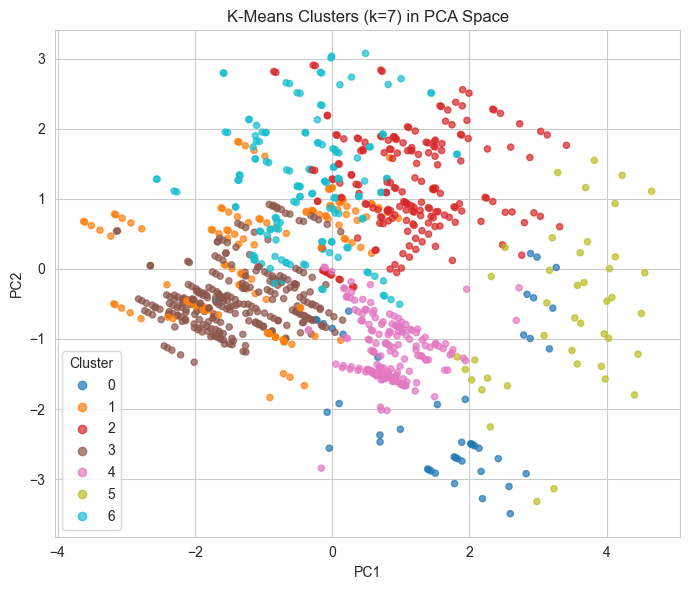

In [22]:
plt.figure(figsize=(7,6))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters (k={best_k}) in PCA Space")
plt.legend(*sc.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig("08_kmeans_clusters_pca.png")
plt.show()

In [23]:
cluster_profile = df.groupby('Cluster')[features + [target]].mean()
cluster_profile['count'] = df.groupby('Cluster').size()
cluster_profile

,cement,slag,ash,water,superplasticizer,coarse_agg,fine_agg,age,strength,count
Cluster,,,,,,,,,,
0,476.648889,30.055556,2.644444,188.011111,2.817556,1071.317778,619.320000,46.777778,49.236937,45
1,399.877953,104.528346,20.188976,158.215748,13.715669,912.963780,812.607874,32.354331,52.771592,127
2,205.328125,188.762760,1.276823,192.744531,2.477083,972.722917,752.714583,31.755208,29.391227,192
3,220.074286,18.227143,125.042143,168.031786,8.581304,1019.174821,806.358393,38.546429,33.681501,280
4,328.696532,0.219653,0.000000,191.294798,0.208671,1010.055491,797.551445,38.682081,26.000539,173
5,327.850000,75.316667,0.000000,218.119048,0.000000,954.057143,678.485714,293.095238,45.224274,42
6,247.332192,90.605479,122.416438,192.602740,8.757945,877.745890,744.555479,27.260274,34.502887,146


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df[features]
Y = df[target]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



In [26]:
from sklearn.preprocessing import StandardScaler

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)


In [27]:
print("X_train_scaled mean (0):",X_train_scaled.mean())
print("X_train_scaled std (1):",X_train_scaled.std())
print("\nX_test_scaled mean (won't be 0, that's expected):",X_test_scaled.mean())



X_train_scaled mean (0): -2.35784305291972e-16
X_train_scaled std (1): 1.0

X_test_scaled mean (won't be 0, that's expected): 0.0027929083460947854


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
Lr = LinearRegression()
Lr.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[12.12, 8.44, 5.44,..., 1.19, 1.67, 6.89]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[43.61,33.72,32.2 ,...,24.86,12.06, 4.96]"


In [30]:
Y_pred_Lr = Lr.predict(X_test_scaled)

r2_Lr = r2_score(Y_test, Y_pred_Lr)

mae_Lr = mean_absolute_error(Y_test, Y_pred_Lr)
rmse_Lr = mean_absolute_error(Y_test, Y_pred_Lr) ** 0.5

print(f"MLR -> R_square:, {r2_Lr:.3f}  MAE: {mae_Lr:.3f}  RSME: {rmse_Lr:.3f}")



MLR -> R_square:, 0.580  MAE: 8.896  RSME: 2.983


In [31]:
coeffs = pd.DataFrame({
    "Features": features,
    "Coefficient": Lr.coef_
}).sort_values("Coefficient", ascending=False)
coeffs

,Features,Coefficient
0,cement,12.116844
1,slag,8.435504
7,age,6.894768
2,ash,5.439802
4,superplasticizer,1.962320
6,fine_agg,1.667185
5,coarse_agg,1.194815
3,water,-2.835449


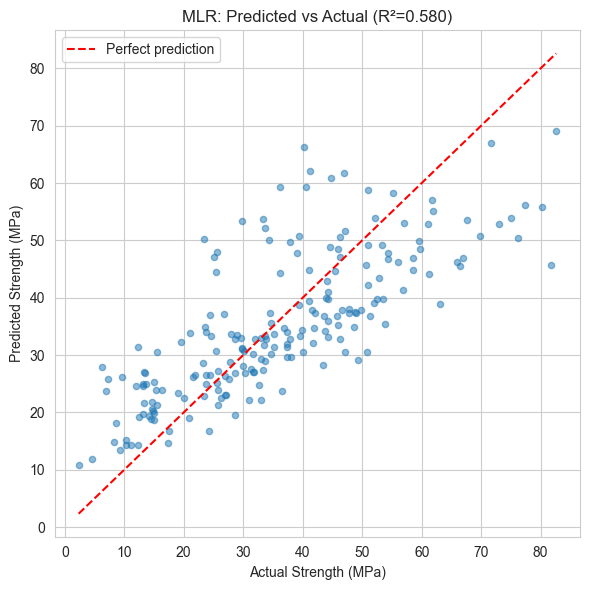

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred_Lr, alpha=0.5, s=20)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label="Perfect prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"MLR: Predicted vs Actual (R²={r2_Lr:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("09_mlr_predicted_vs_actual.png")
plt.show()

In [33]:
from sklearn.neighbors import KNeighborsRegressor


In [34]:
k_values = range(1, 21)
mae_scores = []
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    Y_pred_k = knn.predict(X_test_scaled)
    mae_scores.append(mean_absolute_error(Y_test, Y_pred_k))
    r2_scores.append(r2_score(Y_test, Y_pred_k))

for k, mae, r2 in zip(k_values, mae_scores, r2_scores):
    print(f"k={k}: MAE={mae:.3f}  R_square={r2:.3f}")


k=1: MAE=6.501  R_square=0.711
k=2: MAE=6.233  R_square=0.744
k=3: MAE=6.428  R_square=0.747
k=4: MAE=6.818  R_square=0.727
k=5: MAE=7.100  R_square=0.719
k=6: MAE=7.380  R_square=0.703
k=7: MAE=7.535  R_square=0.687
k=8: MAE=7.503  R_square=0.682
k=9: MAE=7.683  R_square=0.672
k=10: MAE=7.867  R_square=0.658
k=11: MAE=8.033  R_square=0.642
k=12: MAE=8.073  R_square=0.635
k=13: MAE=8.056  R_square=0.632
k=14: MAE=8.059  R_square=0.637
k=15: MAE=8.131  R_square=0.632
k=16: MAE=8.136  R_square=0.631
k=17: MAE=8.355  R_square=0.621
k=18: MAE=8.416  R_square=0.614
k=19: MAE=8.533  R_square=0.605
k=20: MAE=8.584  R_square=0.602


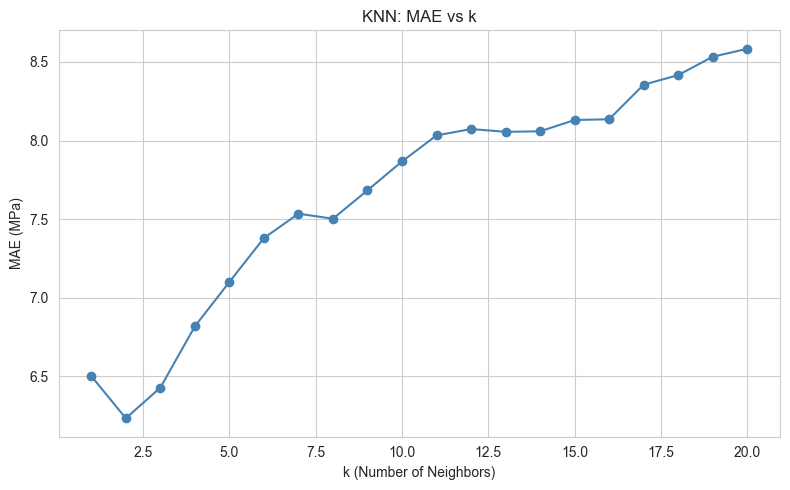

In [35]:
plt.figure(figsize=(8,5))
plt.plot(list(k_values), mae_scores, 'o-', color='steelblue')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("MAE (MPa)")
plt.title("KNN: MAE vs k")
plt.grid(True)
plt.tight_layout()
plt.savefig("10_knn_k_selection.png")
plt.show()

In [36]:
best_k = k_values[mae_scores.index(min(mae_scores))]
print("Best k (lowest MAE):", best_k)

knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, Y_train)
Y_pred_knn = knn_final.predict(X_test_scaled)

r2_knn = r2_score(Y_test, Y_pred_k)
mae_knn = mean_absolute_error(Y_test, Y_pred_knn)
rmse_knn = mean_squared_error(Y_test, Y_pred_knn) ** 0.5

print(f"KNN (k={best_k})  ->  R_square: {r2_knn:.3f} MAE: {mae_knn:.3f}  RMSE: {rmse_knn:.3f}")



Best k (lowest MAE): 2
KNN (k=2)  ->  R_square: 0.602 MAE: 6.233  RMSE: 8.747


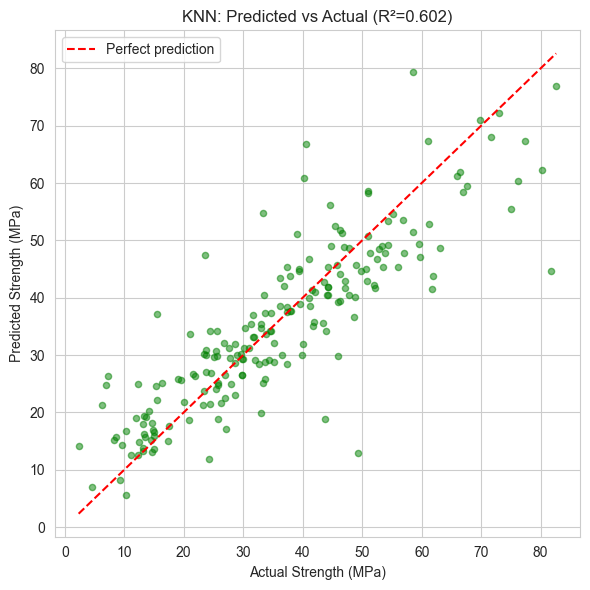

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred_knn, alpha=0.5, s=20, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label="Perfect prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"KNN: Predicted vs Actual (R²={r2_knn:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("11_knn_predicted_vs_actual.png")
plt.show()

In [38]:
# Step-9=====

In [39]:
from sklearn.neural_network import MLPRegressor

In [40]:
ann = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu' , solver='adam',
    max_iter=2000,
    random_state=42
)
ann.fit(X_train_scaled, Y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",

In [41]:
Y_pred_ann = ann.predict(X_test_scaled)

r2_ann = r2_score(Y_test, Y_pred_ann)
mae_ann = mean_absolute_error(Y_test, Y_pred_ann)
rmse_ann = mean_squared_error(Y_test, Y_pred_ann) ** 0.5

print(f"ANN R_square: {r2_ann:.3f} MAE: {mae_ann:.3f} RSME: {rmse_ann:.3f}")


ANN R_square: 0.833 MAE: 5.355 RSME: 7.065


In [42]:
print("Converged after", ann.n_iter_, "iteration")
print("Final loss:", ann.loss_)

Converged after 910 iteration
Final loss: 18.798672392248807


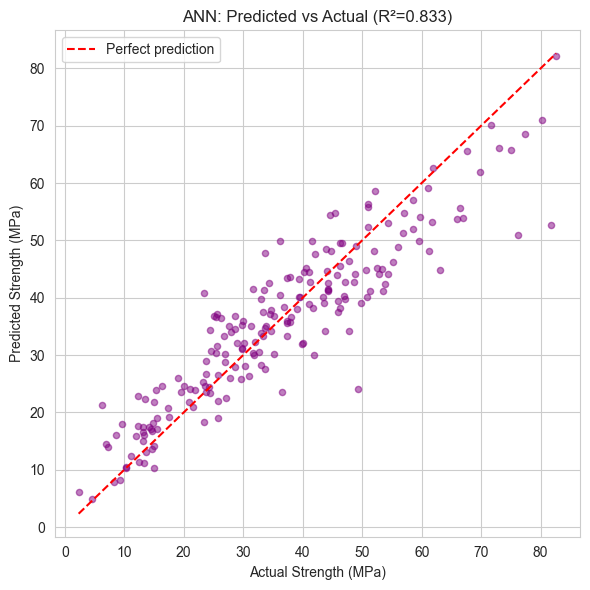

In [43]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred_ann, alpha=0.5, s=20, color='purple')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label="Perfect prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title(f"ANN: Predicted vs Actual (R²={r2_ann:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("12_ann_predicted_vs_actual.png")
plt.show()

In [44]:
for layers in [(16,), (32,16), (64,32,16)]:
    ann_test = MLPRegressor(hidden_layer_sizes=layers, activation='relu',
                            solver='adam', max_iter=3000, random_state=42)
    ann_test.fit(X_train_scaled, Y_train)
    pred = ann_test.predict(X_test_scaled)
    print(f"Layers={layers}: R_square={r2_score(Y_test, pred):.3f}  MAE={mean_absolute_error(Y_test, pred):.3f}")

Layers=(16,): R_square=0.773  MAE=6.220
Layers=(32, 16): R_square=0.833  MAE=5.355
Layers=(64, 32, 16): R_square=0.865  MAE=4.454


In [45]:
comparison = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "K-Nearest Neighbors", "Artificial Neural Network"],
    "R2": [r2_Lr, r2_knn, r2_ann],
    "MAE": [mae_Lr, mae_knn, mae_ann],
    "RMSE": [rmse_Lr, rmse_knn, rmse_ann]

})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)
comparison

,Model,R2,MAE,RMSE
0,Artificial Neural Network,0.832688,5.355108,7.064986
1,K-Nearest Neighbors,0.601644,6.233408,8.746973
2,Multiple Linear Regression,0.580109,8.896028,2.982621


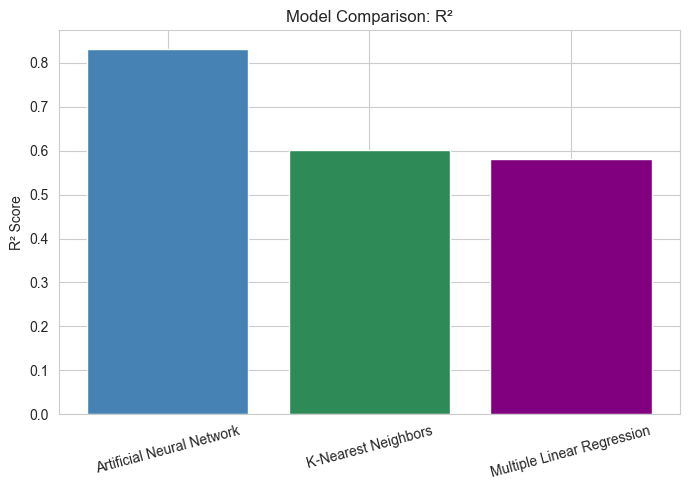

In [46]:
plt.figure(figsize=(7,5))
plt.bar(comparison["Model"], comparison["R2"], color=['steelblue', 'seagreen', 'purple'])
plt.ylabel("R² Score")
plt.title("Model Comparison: R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("13_model_comparison_r2.png")
plt.show()

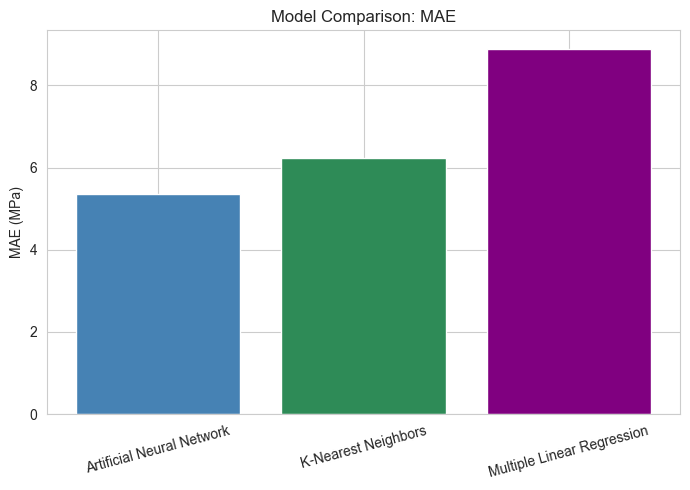

In [47]:
plt.figure(figsize=(7,5))
plt.bar(comparison["Model"], comparison["MAE"], color=['steelblue', 'seagreen', 'purple'])
plt.ylabel("MAE (MPa)")
plt.title("Model Comparison: MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("14_model_comparison_mae.png")
plt.show()

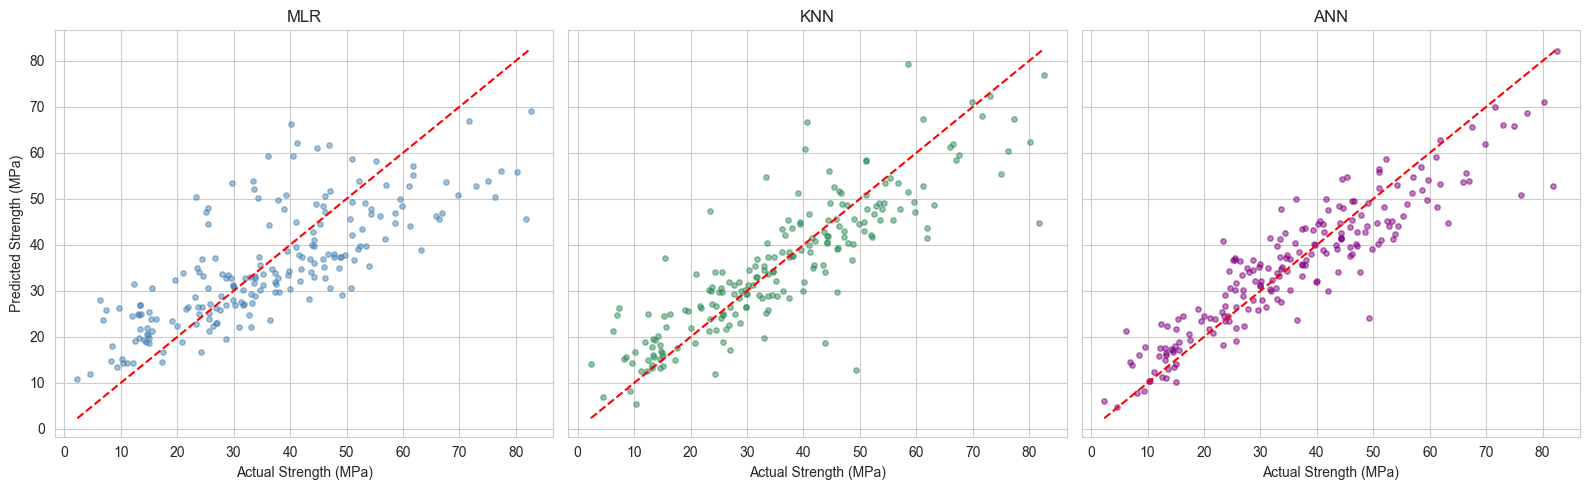

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharex=True, sharey=True)
preds = [Y_pred_Lr, Y_pred_knn, Y_pred_ann]
names = ["MLR", "KNN", "ANN"]
colors = ['steelblue', 'seagreen', 'purple']

for ax, pred, name, color in zip(axes, preds, names, colors):
    ax.scatter(Y_test, pred, alpha=0.5, s=15, color=color)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel("Actual Strength (MPa)")
axes[0].set_ylabel("Predicted Strength (MPa)")
plt.tight_layout()
plt.savefig("15_all_models_comparison.png")
plt.show()

In [49]:
#  step 11
from sklearn.inspection import permutation_importance

In [50]:
print("MLR Coefficients (standardized features, so directly comparable):")
print(coeffs)


MLR Coefficients (standardized features, so directly comparable):
           Features  Coefficient
0            cement    12.116844
1              slag     8.435504
7               age     6.894768
2               ash     5.439802
4  superplasticizer     1.962320
6          fine_agg     1.667185
5        coarse_agg     1.194815
3             water    -2.835449


In [51]:
perm_knn = permutation_importance(knn_final, X_test_scaled, Y_test,
                                   n_repeats=30, random_state=42)

knn_importance = pd.DataFrame({
    "Feature": features,
    "Importance": perm_knn.importances_mean
}).sort_values("Importance", ascending=False)

knn_importance


,Feature,Importance
7,age,0.437535
0,cement,0.316245
1,slag,0.172515
4,superplasticizer,0.169741
3,water,0.159187
2,ash,0.114897
5,coarse_agg,0.099027
6,fine_agg,0.094067


In [52]:
perm_ann = permutation_importance(ann, X_test_scaled, Y_test,
                                    n_repeats=30, random_state=42)

ann_importance = pd.DataFrame({
    "Feature": features,
    "Importance": perm_ann.importances_mean
}).sort_values("Importance", ascending=False)

ann_importance

,Feature,Importance
0,cement,1.284370
7,age,0.781372
1,slag,0.557494
2,ash,0.200086
6,fine_agg,0.079192
5,coarse_agg,0.079139
3,water,0.075236
4,superplasticizer,0.062907


In [53]:


importance_summary = pd.DataFrame({
    "Feature": features,
    "MLR_Coefficient": coeffs.set_index("Features").loc[features, "Coefficient"].values,
    "KNN_Importance": knn_importance.set_index("Feature").loc[features, "Importance"].values,
    "ANN_Importance": ann_importance.set_index("Feature").loc[features, "Importance"].values,
})

importance_summary

,Feature,MLR_Coefficient,KNN_Importance,ANN_Importance
0,cement,12.116844,0.316245,1.284370
1,slag,8.435504,0.172515,0.557494
2,ash,5.439802,0.114897,0.200086
3,water,-2.835449,0.159187,0.075236
4,superplasticizer,1.962320,0.169741,0.062907
5,coarse_agg,1.194815,0.099027,0.079139
6,fine_agg,1.667185,0.094067,0.079192
7,age,6.894768,0.437535,0.781372


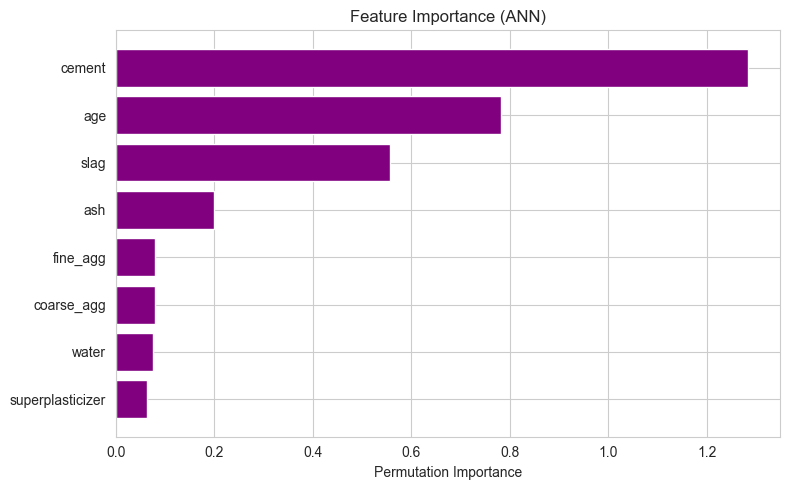

In [54]:
plt.figure(figsize=(8,5))
plt.barh(ann_importance["Feature"], ann_importance["Importance"], color='purple')
plt.xlabel("Permutation Importance")
plt.title("Feature Importance (ANN)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("16_feature_importance_ann.png")
plt.show()

In [55]:
print("Cluster strength ranking (from Step 5):")
print(cluster_profile[[target]].sort_values(target, ascending=False))

Cluster strength ranking (from Step 5):
          strength
Cluster           
1        52.771592
0        49.236937
5        45.224274
6        34.502887
3        33.681501
2        29.391227
4        26.000539
